# qSNOW — Getting Started

[![Render on nbviewer](https://img.shields.io/badge/render-nbviewer-f37726?logo=jupyter&logoColor=white)](https://nbviewer.org/github/JacobSPalmer/qSNOW/blob/main/demo/demo-v2.ipynb)

> The figures in this notebook are embedded as **static images** so they remain visible
> when the notebook is viewed directly on GitHub. For the **fully interactive** Plotly
> views — dropdown view-switching, hover readouts, pan/zoom — open the notebook in
> [nbviewer](https://nbviewer.org/github/JacobSPalmer/qSNOW/blob/main/demo/demo-v2.ipynb)
> (badge above) or run it locally.

**qSNOW** (*Simulated Noise Orchestration Workflow*) is an extendable toolbox for
orchestrating chip-wide performance experiments on quantum error-correcting (QEC) codes.
It ingests [Stim](https://github.com/quantumlib/Stim) circuits, situates them on a model
of a physical chip, and injects **heterogeneous noise** through a composable rule system.

Superconducting devices exhibit considerable qubit-to-qubit variation and are poorly
described by a uniform noise model. qSNOW is built to treat the physical error rate as a
*distribution* across the lattice rather than a single global value, making questions of
the following form tractable: *given a fixed chip under a heterogeneous noise model, where
may a logical qubit be placed such that it remains below its **boundary of acceptable
defectiveness (BAD)** — the physical error rate past which a defective qubit degrades the
logical computation beyond an algorithm's target logical error rate?*

This notebook is a structured walkthrough of the core object model. It covers:

1. constructing a **`Chip`** — a checkerboard lattice of physical qubits;
2. populating it with a **noise model**, and the family of samplers qSNOW provides;
3. placing and manipulating **`LogicalTile`s** (rotated surface-code patches);
4. **injecting noise** into circuits on demand via a **`Ruleset`**;
5. **packing heterogeneous logical patches** onto a single, shared chip;
6. orchestrating a **`SquarePackingExp`** to sample logical error rates with `sinter`;
7. **serializing** the resulting configurations to portable `.flake` files.

> **Prerequisites** — qSNOW installed in editable mode (`pip install -e ".[test]"`),
> with the `qsnow` environment selected as this notebook's kernel.


## Architecture at a glance

Source resides under `src/qsnow/` and is partitioned into four subpackages:

| Subpackage | Responsibility |
|---|---|
| **`interface/`** | The core object model — `Grid`, `Chip`, `LogicalTile`, the noise-injection `Ruleset`, and code-specific tiles (`SCTile`). |
| **`visualize/`** | Plotly-based rendering — `chip.show()` and swappable *style functions* (`Qubit → QubitStyle`). |
| **`experiments/`** | Experiment orchestration — the `Experiment` base class and `SquarePackingExp`. |
| **`helpers/`** | Serialization — round-tripping objects to and from `.flake` files. |

The governing design principle is a strict separation between the **physical layer**
(the `Chip` and its per-qubit noise) and the **logical layer** (a `LogicalTile` wrapping
a Stim circuit). Noise is deliberately *not* baked into the circuit: it is re-injected
on demand from the chip's noise map whenever `tile.circuit` is accessed, driven by rules
that fire on named Stim operations. Consequently, relocating a patch or reshaping the
noise field changes the emitted circuit without any explicit recompilation step.


## 1. Setup

The public API is re-exported from the `qsnow.interface`, `qsnow.visualize`,
`qsnow.experiments`, and `qsnow.helpers` packages.


In [1]:
import sys

import numpy as np
import stim
import plotly.io as pio

# --- Core object model -------------------------------------------------
from qsnow.interface import Chip, LogicalTile, SCTile, Status, CSSType, Tag, TileSpec

# --- Visualization styles ---------------------------------------------
from qsnow.visualize import default_style, css_style, noise_heatmap_style, export_html

# --- Experiments & serialization --------------------------------------
from qsnow.experiments import SquarePackingExp, ExperimentResults
from qsnow.helpers import serialize

# Figures are emitted in two representations. "plotly_mimetype" is the interactive
# Plotly figure, rendered natively by VS Code, JupyterLab, and nbviewer; "png" embeds a
# static image so the figures remain visible on GitHub, which does not execute the
# interactive representation. The script-bearing HTML representation is intentionally
# omitted: GitHub prioritizes (and then sanitizes) it, which would blank the figures.
pio.renderers.default = "plotly_mimetype+png"
np.set_printoptions(precision=4, suppress=True)

import qsnow
print("Python :", sys.version.split()[0])
print("Stim   :", stim.__version__)
print("qSNOW  :", qsnow.__file__)

Python : 3.13.14
Stim   : 1.16.0
qSNOW  : /Users/jakepalmer/Code/Projects/qSNOW/src/qsnow/__init__.py


## 2. The `Chip` — a checkerboard of physical qubits

`Chip(L, H)` constructs a physical chip as a **checkerboard integer lattice**.
Internally it spans a `2L × 2H` grid, and a coordinate `(x, y)` is occupied by a qubit
**iff `x % 2 == y % 2`** (both even or both odd). This checkerboard invariant is enforced
throughout the library — qubit positions, tile origins, and every shift respect it.

`chip.summary()` returns the compact descriptive facts; `chip.show()` renders an
interactive figure with a dropdown to switch between the standard views (status /
CSS type / noise).


In [2]:
chip = Chip(5, 5)
chip.summary()

{'unit_size': (5, 5),
 'grid_size': (10, 10),
 'n_qubits': 50,
 'n_tiles': 0,
 'noise_model': None}

In [3]:
# Every occupied coordinate holds a Qubit carrying a location, status, CSS type, and noise.
print("Number of qubits :", len(chip.qubits))
print("A single qubit   :", chip.loc((2, 2)))

Number of qubits : 50
A single qubit   : Qubit(loc=(2, 2), status=Status.INACTIVE, type=CSSType.UNASSIGNED, noise=NoiseProfile(p=0.0))


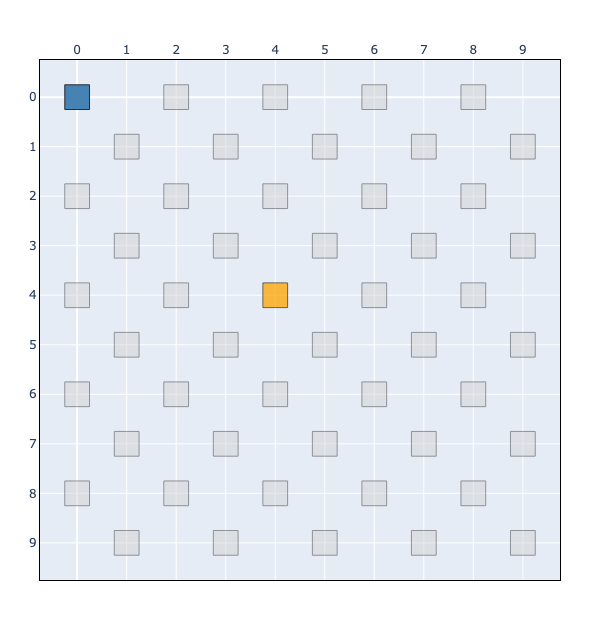

In [4]:
# A qubit's status records whether the site participates in a logical patch.
chip.loc((0, 0)).status = Status.LOGICAL
chip.loc((4, 4)).status = Status.ANCILLA
chip.show(style=default_style)

## 3. Noise models

Real superconducting processors are heterogeneous: physical error rates vary
substantially across the lattice and are frequently correlated in space. Modeling this
heterogeneity faithfully is precisely why qSNOW represents noise as a per-qubit field
rather than a single global parameter.

Every qubit carries a `NoiseProfile` exposing a physical error rate `p` (a bounded float
on `[0, 0.75]`). `Chip` provides a family of *samplers* that populate `p` across the
lattice, each recording its parameters in the chip's metadata for provenance:

- **`generate_uniform_noise(p)`** — a homogeneous field; every qubit shares a single `p`.
- **`generate_random_noise(range)`** — independent draws from a uniform distribution
  over `range`.
- **`generate_gaussian_noise(mean, deviation)`** — independent draws from a truncated
  Gaussian.
- **`generate_derived_contour_noise(mean, deviation, slope=...)`** — a *spatially
  correlated* gradient, in which each site's error rate is derived from a smoothed
  neighborhood average, producing the contoured, non-i.i.d. structure characteristic of
  real devices.

Each stochastic sampler accepts a `seed` for reproducibility. Below we visualize the
three non-trivial fields with `noise_heatmap_style`, moving from fully independent
(Gaussian, random) to spatially correlated (contour).


noise model : {'name': 'gaussian', 'mean': 0.01, 'deviation': 0.003, 'seed': 42}
p at (2, 2) : 0.01278


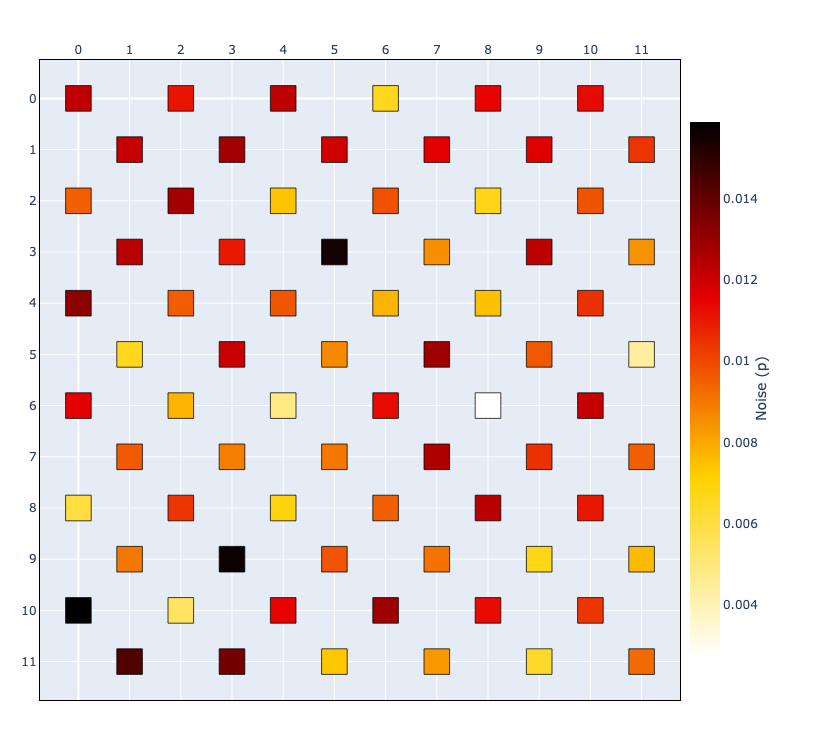

In [3]:
# (a) Truncated-Gaussian field: i.i.d. draws about a target mean.
chip = Chip(6, 6)
chip.generate_gaussian_noise(mean=0.010, deviation=0.003, seed=42)

print("noise model :", chip.summary()["noise_model"])
print("p at (2, 2) :", chip.loc((2, 2)).noise.p)
chip.show(style=noise_heatmap_style(chip))

noise model : {'name': 'uniform random', 'range': (0.005, 0.02), 'seed': 11}


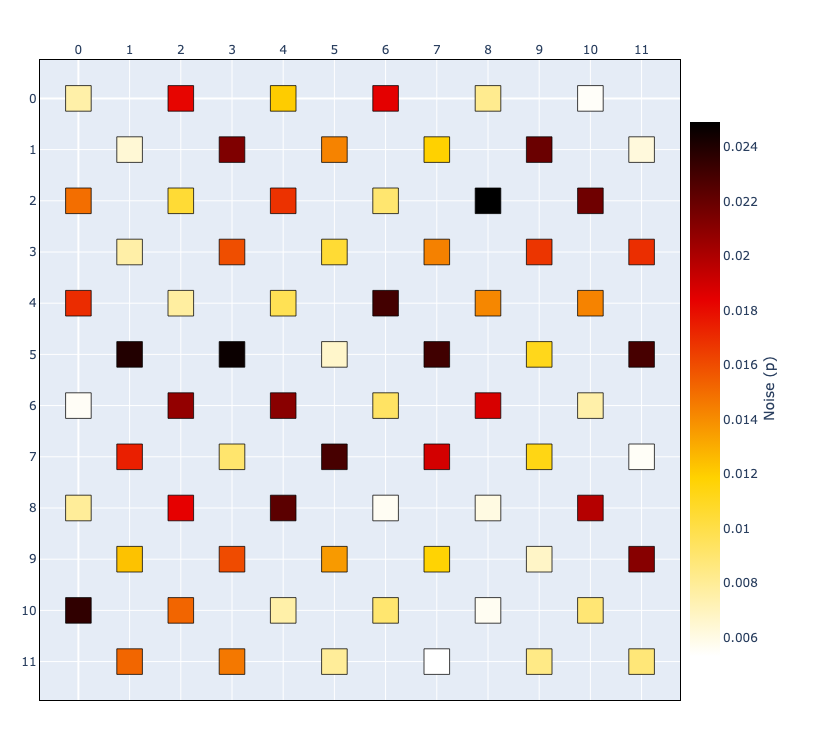

In [4]:
# (b) Uniform-random field over an explicit interval.
chip_rand = Chip(6, 6)
chip_rand.generate_random_noise(range=(0.005, 0.020), seed=11)
print("noise model :", chip_rand.summary()["noise_model"])
chip_rand.show(style=noise_heatmap_style(chip_rand))

### Spatially correlated noise

The samplers above draw each qubit independently, which is convenient but unphysical:
real fabrication variation is *correlated* in space. `generate_derived_contour_noise`
constructs such a field — neighboring qubits take on similar error rates, yielding smooth
gradients and hot spots. The `slope` parameter controls the spatial scale of the
correlation. On a larger chip the contour structure is readily apparent in the heatmap.


12
noise model : {'name': 'derived contour', 'mean': 0.005, 'deviation': 0.002, 'slope': 5, 'seed': 12}


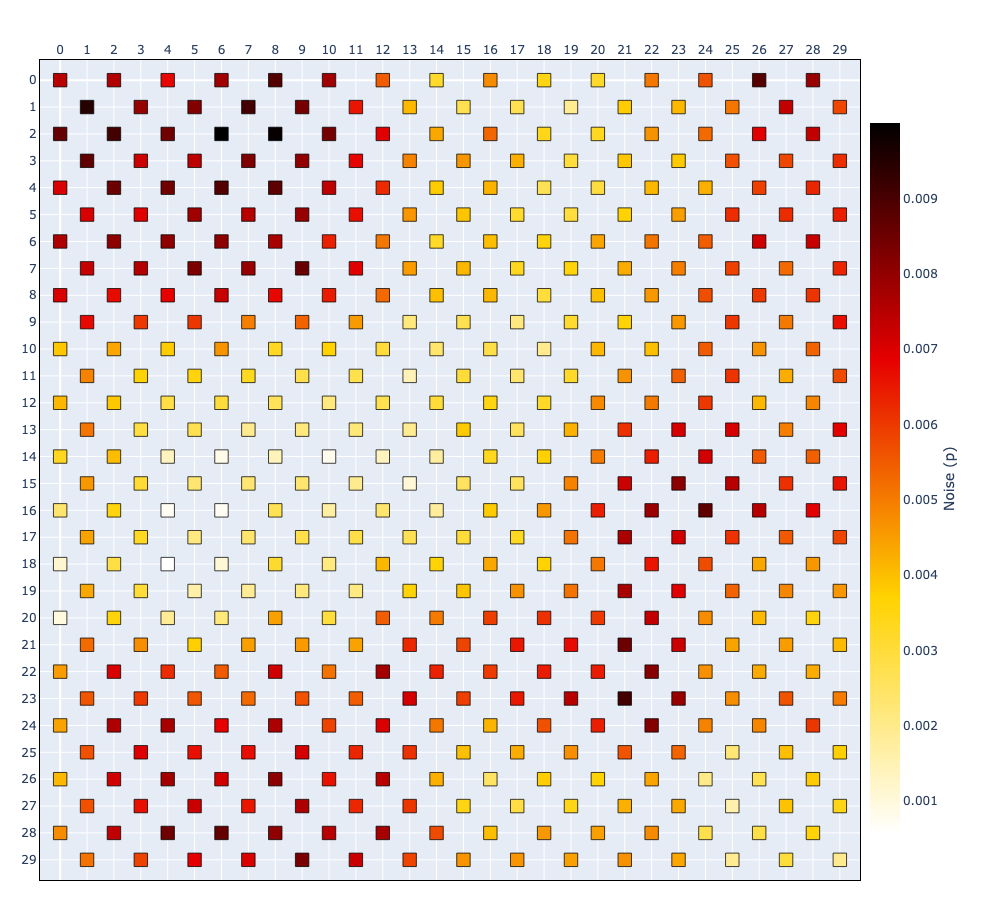

NoiseProfile(p=0.0005599892778335716)


In [9]:
chip_contour = Chip(15, 15)
chip_contour.generate_derived_contour_noise(mean=0.005, deviation=0.002, seed=12, slope=5)
print("noise model :", chip_contour.summary()["noise_model"])
chip_contour.show(style=noise_heatmap_style(chip_contour))
print(min(chip_contour.noise_map.values()))


## 4. Logical tiles — placing a surface code

A **`LogicalTile`** wraps a Stim circuit anchored to a coordinate frame. The
code-specific subclass **`SCTile`** generates a *rotated surface code* of a given
`distance` and assigns each qubit a **CSS type** (`DATA`, `X_CHECK`, `Z_CHECK`,
`BUFFER`).

A tile is placed with `chip.add_tile(tile, loc)`, where `loc` is the tile's origin (its
upper-left qubit). Placement is validated against the checkerboard invariant, the chip
bounds, and overlap with existing tiles. Here we color qubits by CSS type via
`css_style`.


tile summary: {'type': 'RSC', 'dims': (4, 4), 'distance': 3}


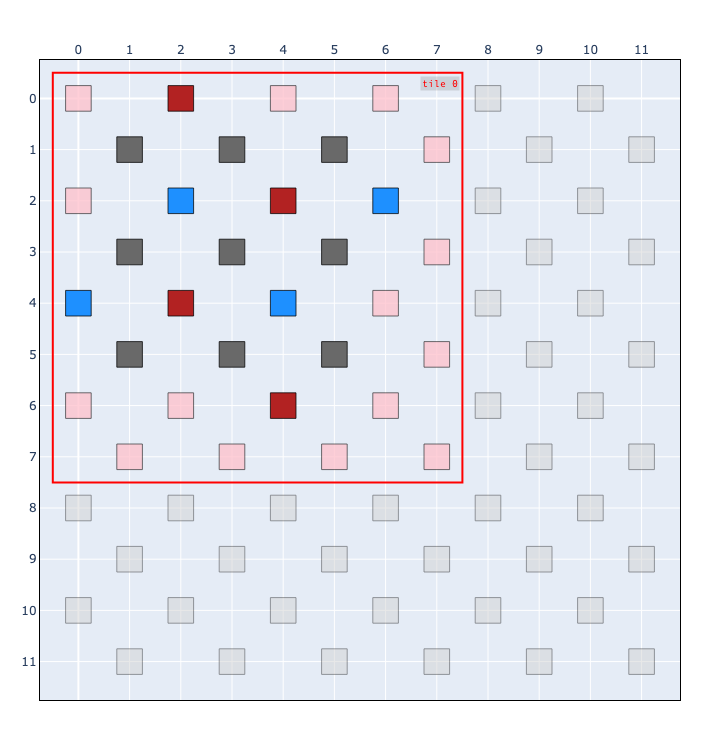

In [8]:
chip = Chip(6, 6)
tile = SCTile(distance=3, rounds=3, task="memory_z")
chip.add_tile(tile)          # no loc -> placed at the tile's own origin (0, 0)

print("tile summary:", tile.summary())
chip.show(style=css_style)

### Relocating tiles

A placed tile may be translated with `shift_to(origin)` or `shift_by(dx, dy)`. A shift
rewrites the `QUBIT_COORDS` within the circuit and transfers qubit statuses, keeping the
physical and logical layers consistent. Every shift must preserve the checkerboard
invariant (`dx % 2 == dy % 2`).


tile origin is now: (2.0, 2.0)


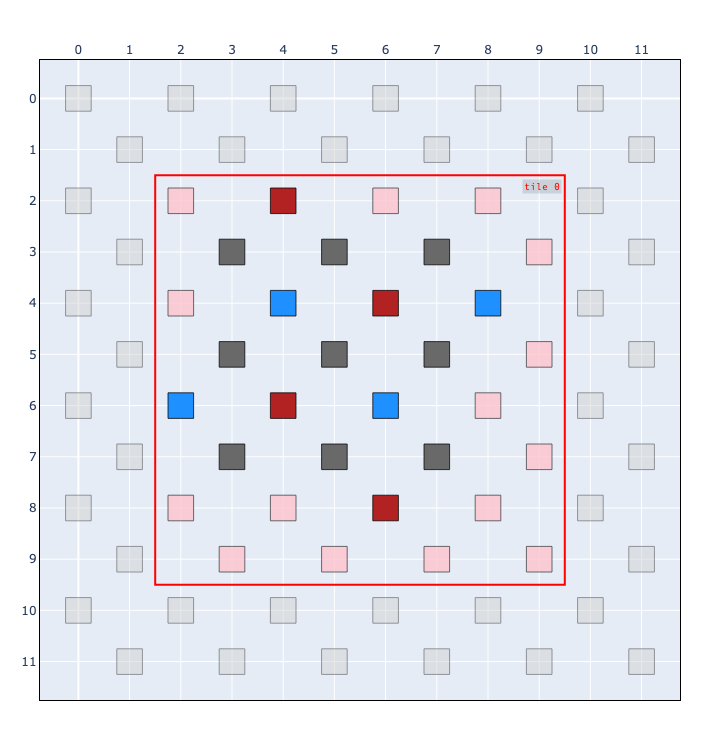

In [9]:
chip.tiles[0].shift_to((2, 2))
print("tile origin is now:", chip.tiles[0].origin)
chip.show(style=css_style)

## 5. Noise injection — coupling the physical and logical layers

This is the heart of qSNOW. A tile holds a **`Ruleset`**: an ordered (priority) list of
`InjectionRule`s. Each rule fires on a named Stim operation (e.g. `CX`, `MR`, `R`) when
its **trigger** — a predicate over the operation's target qubits — passes, and applies
noise **channels** (e.g. `DEPOLARIZE2`, `X_ERROR`) to the qubits selected by a named
**filter**, *before* and/or *after* the operation.

`SCTile` supplies a representative default ruleset:


In [10]:
print(tile._ruleset)

0:R:all_qubits
1:H:x_measures
2:CX:any
3:MR:all_measures
4:M:data


Accessing **`tile.circuit`** walks the base circuit and re-injects noise channels
using each qubit's `noise.p` drawn from the chip. Because injection reads the chip's live
noise map, altering the noise or relocating the tile alters the emitted circuit — nothing
is baked in. For diagnostics, each injected channel can additionally be **tagged** with
the rule that produced it; Stim tags are inert annotations, useful for downstream
tooling.

We assign a sub-threshold noise level and inspect the injected circuit.


In [11]:
chip.generate_gaussian_noise(mean=0.005, deviation=0.0006, seed=7)

noisy_circuit = tile.circuit          # re-injected on every access
print(type(noisy_circuit).__name__,
      f"| {noisy_circuit.num_qubits} qubits, {noisy_circuit.num_ticks} ticks\n")

# The injected channels' probabilities are the mean physical error rate of the qubits
# each channel acts on, drawn live from the chip's noise map.
noise_ops = ("DEPOLARIZE", "X_ERROR", "Y_ERROR", "Z_ERROR")
injected = [ln for ln in str(noisy_circuit).splitlines()
            if ln.lstrip().startswith(noise_ops)]
print(f"{len(injected)} injected noise instructions. First few:\n")
print("\n".join(injected[:6]))

# With provenance tags, each channel names the exact rule (operation:trigger ->
# channel:filter) that produced it:
tagged = tile._inject_circuit_noise(debug_tags=True)
tagged_lines = [ln for ln in str(tagged).splitlines()
                if ln.lstrip().startswith(noise_ops)]
print("\nWith provenance tags:\n")
print("\n".join(tagged_lines[:6]))

Circuit | 26 qubits, 21 ticks

258 injected noise instructions. First few:

X_ERROR(0.00637) 1
X_ERROR(0.00502) 2
X_ERROR(0.00459) 3
X_ERROR(0.00561) 5
X_ERROR(0.00453) 8
X_ERROR(0.00495) 9

With provenance tags:

X_ERROR[R:all_qubits -> X_ERROR:all_qubits](0.00637) 1
X_ERROR[R:all_qubits -> X_ERROR:all_qubits](0.00502) 2
X_ERROR[R:all_qubits -> X_ERROR:all_qubits](0.00459) 3
X_ERROR[R:all_qubits -> X_ERROR:all_qubits](0.00561) 5
X_ERROR[R:all_qubits -> X_ERROR:all_qubits](0.00453) 8
X_ERROR[R:all_qubits -> X_ERROR:all_qubits](0.00495) 9


Because the result is a genuine Stim circuit, the entire Stim ecosystem applies
directly — for instance, compiling a detector-error model for a decoder:


In [12]:
dem = noisy_circuit.detector_error_model(decompose_errors=True)
print("Detectors        :", noisy_circuit.num_detectors)
print("DEM error terms  :", dem.num_errors)

Detectors        : 24
DEM error terms  : 286


## 6. Packing heterogeneous logical patches

A chip is a workspace for *many* tiles, and `add_tile` rejects overlapping or
out-of-bounds placements. Patches of **different code distances** may therefore be tiled
together over a shared, non-uniform noise field — the setting in which packing questions
become interesting. Use `tile.copy()` (or a fresh constructor) to stamp independent,
uninitialized patches.

The layout below combines a row of three `d=3` patches with a `d=5` and a `d=7` patch,
first colored by CSS type, then overlaid on the underlying noise.


Placed 5 patches: distances [3, 3, 3, 5, 7]


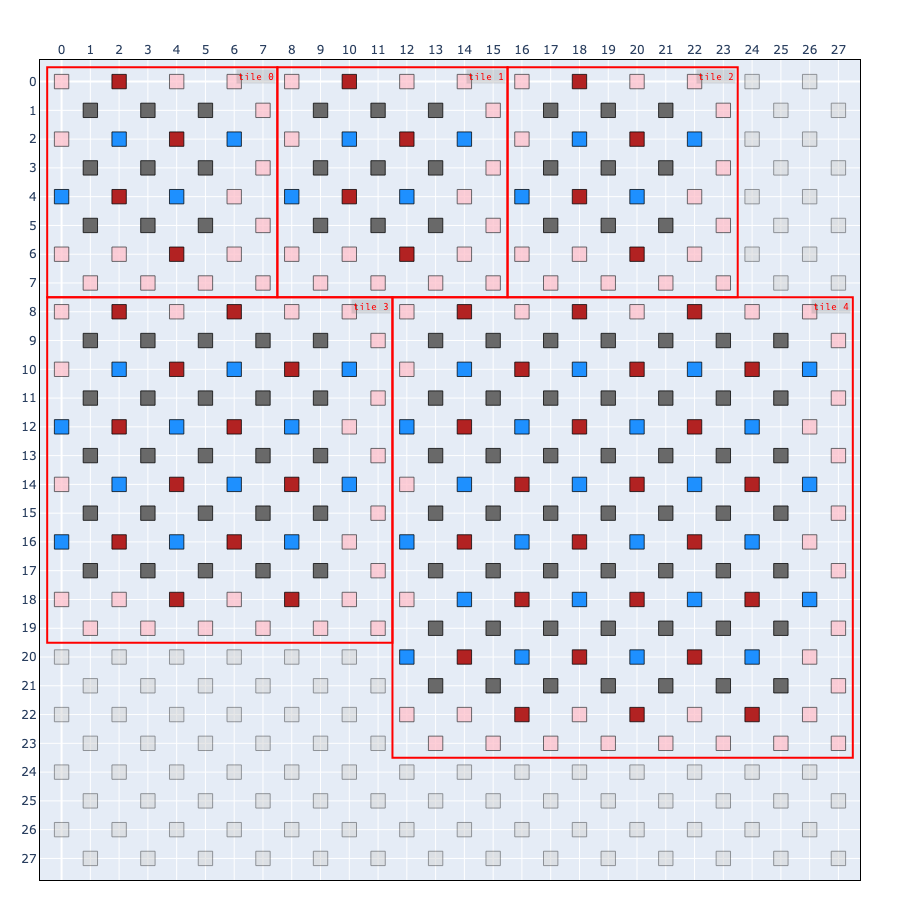

In [13]:
chip = Chip(14, 14)
chip.generate_gaussian_noise(mean=0.012, deviation=0.004, seed=3)

placements = [
    (SCTile(distance=3), (0, 0)),
    (SCTile(distance=3), (8, 0)),
    (SCTile(distance=3), (16, 0)),
    (SCTile(distance=5), (0, 8)),
    (SCTile(distance=7), (12, 8)),
]
for patch, loc in placements:
    chip.add_tile(patch, loc)

print(f"Placed {len(chip.tiles)} patches: "
      f"distances {sorted(t.spec.distance for t in chip.tiles)}")
chip.show(style=css_style)

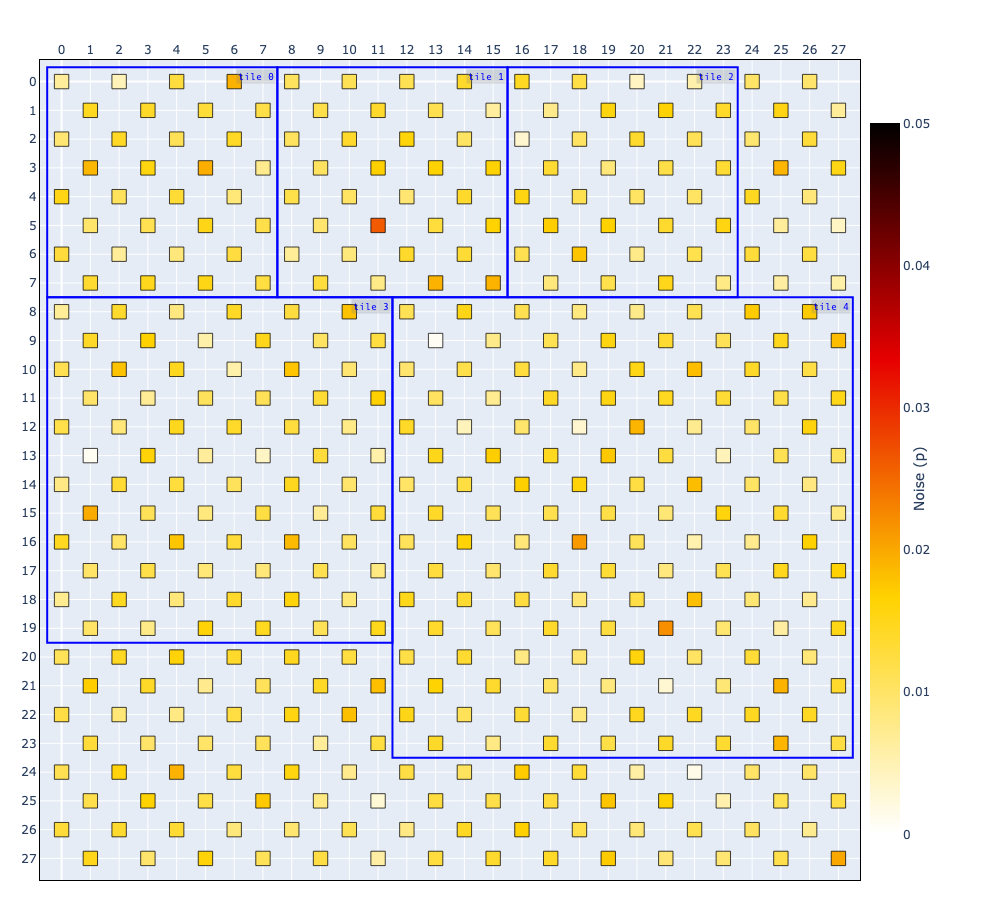

In [14]:
# The same heterogeneous layout, overlaid on the physical error rate:
chip.show(style=noise_heatmap_style(chip, limits=(0.0, 0.05)))

## 7. An experiment: `SquarePackingExp`

Experiments are abstractions built *with* the toolbox to answer a specific question.
`SquarePackingExp` sweeps a tile across **every valid placement** on a chip, constructs
the noise-injected circuit at each candidate site, and estimates the **logical error rate
(LER)** with [`sinter`](https://github.com/quantumlib/Stim). Rather than treating each
qubit as either nominal or unusable, the sweep asks where a patch can *tolerate* the
surrounding heterogeneity: the result exposes which regions of a noisy chip can host a
logical qubit within its target performance — i.e., below the BAD threshold.

The run below is deliberately small (few placements, few shots) so that it completes
quickly; production runs use far larger shot counts.


In [15]:
exp_chip = Chip(7, 7)
exp_chip.generate_gaussian_noise(mean=0.006, deviation=0.0015, seed=3)

exp = SquarePackingExp(exp_chip, SCTile(distance=3))
print("Candidate placements to sample:", len(exp.profile))

Candidate placements to sample: 25


In [16]:
results = exp.run(shots=1_000, max_errors=200, max_workers=4)

# results maps each placement origin -> its sampled logical error rate
for loc, stat in list(results.items())[:5]:
    print(f"  origin {loc}: LER = {stat['ler']:.4f}  ({stat['errors']}/{stat['shots']})")
print(f"  ... {len(results)} placements total")

Experiment: SquarePackingExp



[1/2] Generating circuits:   0%|                                                                                                         | 0/25 [00:00<?, ?it/s]


[1/2] Generating circuits: 100%|███████████████████████████████████████████████████████████████████████████████████████████████| 25/25 [00:00<00:00, 385.31it/s]


[2/2] Sampling circuits:   0%|                                                                                                           | 0/25 [00:00<?, ?it/s]


[2/2] Sampling circuits: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████| 25/25 [00:00<00:00, 32.08it/s]


[2/2] Sampling circuits: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████| 25/25 [00:00<00:00, 32.03it/s]

  origin (0, 4): LER = 0.0820  (82/1000)
  origin (0, 0): LER = 0.0790  (79/1000)
  origin (0, 2): LER = 0.0790  (79/1000)
  origin (0, 6): LER = 0.0900  (90/1000)
  origin (2, 0): LER = 0.0820  (82/1000)
  ... 25 placements total


`exp.show(...)` renders the run as an interactive figure with a dropdown across the
per-qubit error rate (PER), the candidate placement sites, the mean PER under each
footprint, and the sampled LER.


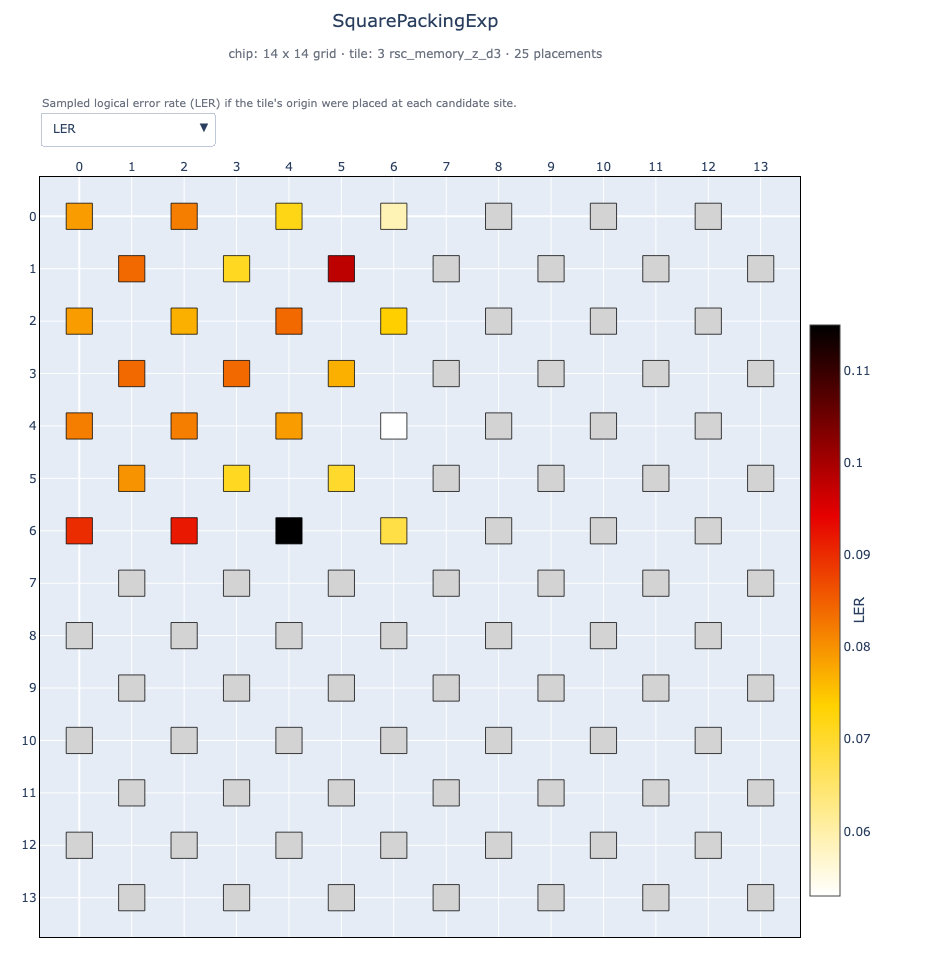

In [17]:
run = ExperimentResults(
    experiment_ref=None,
    run_config=exp.config,
    results=exp.results,
)
exp.show(run)

## 8. Serialization — qSNOW *flakes*

Every qSNOW object supports export as a **`.flake`** file: a serialized qSNOW
configuration capturing everything required to reconstruct the object. The serialization
library thus supports **round-tripping** (1:1 import/export) of `Chip`, `LogicalTile`
(and code subclasses such as `SCTile`), and `Experiment` (currently `SquarePackingExp`)
through `.flake` JSON. Any object is serialized with `serialize.export_flake(obj)`, which
writes to a location determined by the global data directory and an object-specific
naming scheme:

```python
export_flake(chip)                    # -> data/chips/chip_<L>x<H>_<timestamp>.flake
export_flake(tile)                    # -> data/tiles/tile_rsc_memory_z_d3_<timestamp>.flake
export_flake(experiment, label='e1')  # -> data/experiments/experiment_e1_<timestamp>.flake
chip = import_latest("chip")          # newest export matching the pattern
chip = import_flake("data/chips/chip_5x5_2026-07-10_12-00-00.flake")
export_flake(chip, "somewhere/else.flake")   # an explicit path is honored, bypassing the naming scheme
```

A few semantics are worth stating explicitly:

- **Chips do not store qubit statuses or CSS types.** They are re-derived on import by
  re-placing each tile through `add_tile`, so the reconstruction is faithful without
  duplicating derived state.
- **Custom triggers/filters cannot be serialized.** They hold live callables; a warning
  is emitted on export, and only the default (named) rules survive the round trip.
- **New tile subclasses** must be registered via `register_tile_type()` to be importable.


In [18]:
# Export the chip, a fresh tile, and the experiment. Each lands in its own subfolder.
chip_path = serialize.export_flake(chip, label="getting_started_chip")
tile_path = serialize.export_flake(SCTile(distance=3), label="rsc_d3")
exp_path  = serialize.export_flake(exp, label="getting_started_sp")

data_dir = serialize.get_data_dir()
for p in (chip_path, tile_path, exp_path):
    print("wrote:", p.relative_to(data_dir))

wrote: chips/chip_getting_started_chip_2026-08-07_14-03-13.flake
wrote: tiles/tile_rsc_d3_2026-08-07_14-03-13.flake
wrote: experiments/experiment_getting_started_sp_2026-08-07_14-03-13.flake


In [19]:
# Reconstruct objects from disk. import_flake takes an explicit path; import_latest
# resolves the newest export matching a glob pattern.
restored_chip = serialize.import_flake(chip_path)
restored_exp = serialize.import_latest("*getting_started_sp*")

print("restored chip:", restored_chip.summary())
print("restored exp :", type(restored_exp).__name__, "->", restored_exp.summary())

Found 3 matching flakes...
Importing flake at /Users/jakepalmer/Code/Projects/qSNOW/data/experiments/experiment_getting_started_sp_2026-08-07_14-03-13.flake
restored chip: {'unit_size': (14, 14), 'grid_size': (28, 28), 'n_qubits': 392, 'n_tiles': 5, 'noise_model': {'name': 'gaussian', 'mean': 0.012, 'deviation': 0.004, 'seed': 3}}
restored exp : SquarePackingExp -> {'chip': {'unit_size': (7, 7), 'grid_size': (14, 14), 'n_qubits': 98, 'n_tiles': 0, 'noise_model': {'name': 'gaussian', 'mean': 0.006, 'deviation': 0.0015, 'seed': 3}}, 'tile': {'type': 'RSC', 'dims': (4, 4), 'distance': 3}, 'placements': 25}


### Relocating the data directory

The default export root is `data/` at the repository root. It can be redirected with
`serialize.set_data_dir(...)`, which is useful for keeping a run's artifacts self-
contained (passing `None` restores the default):

```python
serialize.set_data_dir('/path/to/flakes')
export_flake(tile, label='processor_config_1')   # -> /path/to/flakes/tiles/tile_processor_config_1_<timestamp>.flake
tile = serialize.import_latest('tile*config_1')  # matches the export above
serialize.set_data_dir(None)                     # restore the default
```

### Standalone interactive visuals

`Chip` and `SquarePackingExp` can additionally be exported as self-contained interactive
HTML pages via `visualize.export_html(obj)`, bundling every applicable default style so
the figure remains fully interactive without a running kernel. *(Experiment exports
require the run's results, passed as the `results` keyword.)*


In [20]:
html_path = export_html(chip, label="getting_started_chip")
print("wrote standalone HTML:", html_path.relative_to(serialize.get_data_dir()))

wrote standalone HTML: html/chip_getting_started_chip_2026-08-07_14-03-18.html
